0. Dataset Overview

· ID:ID Number of Customers

· Warehouse_block:The Company have big Warehouse which is divided into block such as A,B,C,D,E

· Mode_of_Shipment:The Company Ships the products in multiple way such as Ship, Flight and Road

· Customer_care_calls:The number of calls made from enquiry for enquiry of the shipment


· Customer_rating:The company has rated from every customer. 1 is the lowest (Worst), 5 is the highest (Best)


· Cost_of_the_Product:Cost of the Product in US Dollars


· Prior_purchases:The Number of Prior Purchase


· Product_importance:The company has categorized the product in the various parameter such as low, medium, high


· Gender:Male and Female


· Discount_offered:Discount offered on that specific product


· Weight_in_gms:It is the weight in grams


· Reached.on.Time_Y.N:It is the target variable, where 1 Indicates that the product has NOT reached on time and 0 indicates it has reached on time

📌 1. Import Required Libraries

In [113]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE


# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


📌 2. Load Dataset

In [114]:
df = pd.read_csv("E_Commerce(in).csv")
df


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


🔹 Drop ID Column

In [115]:
df.drop('ID', axis=1, inplace=True)

📌 3. Dataset Information

In [116]:
df.shape


(10999, 11)

In [117]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Warehouse_block      10999 non-null  object
 1   Mode_of_Shipment     10999 non-null  object
 2   Customer_care_calls  10999 non-null  int64 
 3   Customer_rating      10999 non-null  int64 
 4   Cost_of_the_Product  10999 non-null  int64 
 5   Prior_purchases      10999 non-null  int64 
 6   Product_importance   10999 non-null  object
 7   Gender               10999 non-null  object
 8   Discount_offered     10999 non-null  int64 
 9   Weight_in_gms        10999 non-null  int64 
 10  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(7), object(4)
memory usage: 945.4+ KB


In [118]:
df.describe()



,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


📌 4. Target Variable Analysis

In [119]:
df['Reached.on.Time_Y.N'].value_counts()


Reached.on.Time_Y.N
1    6563
0    4436
Name: count, dtype: int64

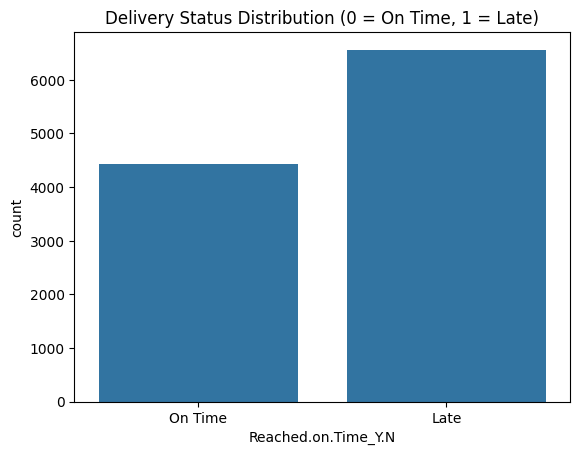

In [120]:
sns.countplot(x='Reached.on.Time_Y.N', data=df)
plt.title("Delivery Status Distribution (0 = On Time, 1 = Late)")
plt.xticks([0, 1], ['On Time', 'Late'])
plt.show()


📌 5. Exploratory Data Analysis (EDA)

🔹 Warehouse Block vs Delivery


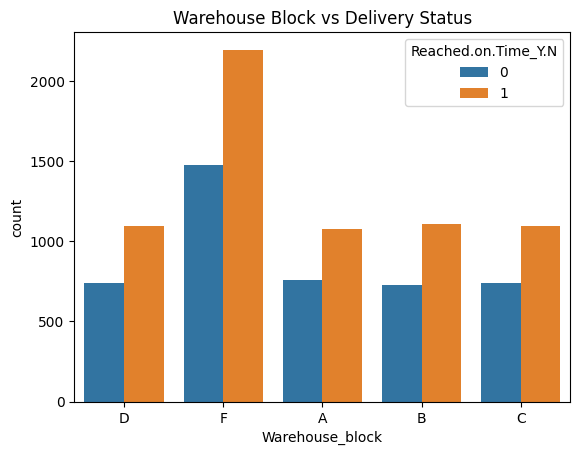

In [121]:
sns.countplot(x='Warehouse_block', hue='Reached.on.Time_Y.N', data=df)
plt.title("Warehouse Block vs Delivery Status")
plt.show()


🔹 Shipping Mode vs Delivery

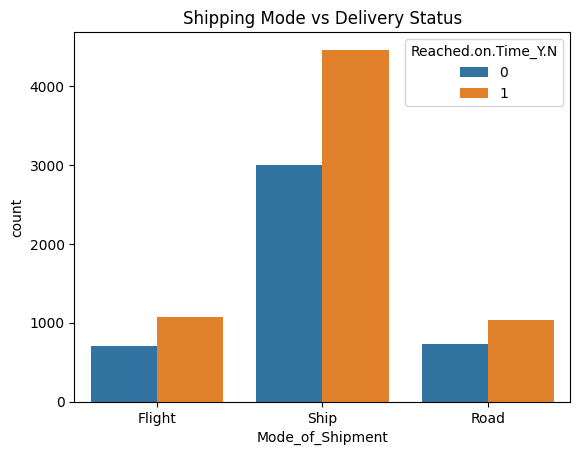

In [122]:
sns.countplot(x='Mode_of_Shipment', hue='Reached.on.Time_Y.N', data=df)
plt.title("Shipping Mode vs Delivery Status")
plt.show()


🔹 Customer Care Calls

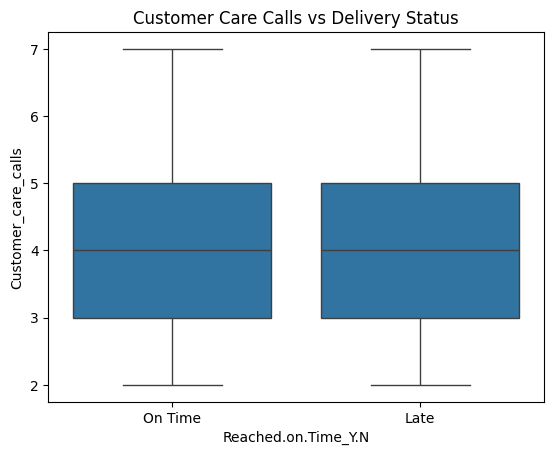

In [123]:
sns.boxplot(x='Reached.on.Time_Y.N', y='Customer_care_calls', data=df)
plt.xticks([0, 1], ["On Time", "Late"])
plt.title("Customer Care Calls vs Delivery Status")
plt.show()


🔹 Relationship between Product Importance and Delay

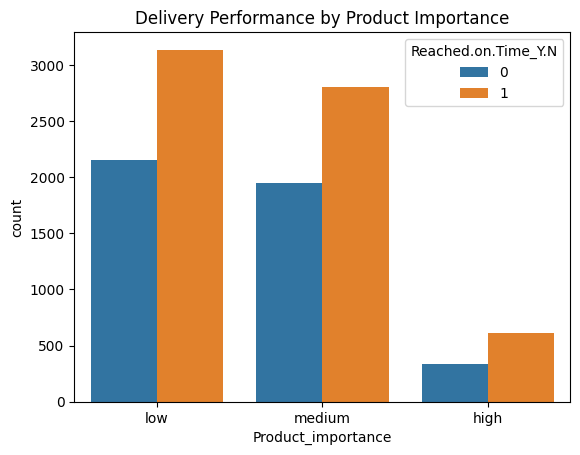

In [124]:
sns.countplot(x='Product_importance', hue='Reached.on.Time_Y.N', data=df)
plt.title("Delivery Performance by Product Importance")
plt.show()


📌 6. Data Preprocessing

🔹 Encode Categorical Variables

In [125]:
le = LabelEncoder()

categorical_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
df .head()


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,3,0,4,2,177,3,1,0,44,1233,1
1,4,0,4,5,216,2,1,1,59,3088,1
2,0,0,2,2,183,4,1,1,48,3374,1
3,1,0,3,3,176,4,2,1,10,1177,1
4,2,0,2,2,184,3,2,0,46,2484,1


🔹 Check Missing Values

In [126]:
df.isnull().sum()


Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

📌 7. Feature Selection & Split

🔹 Features & Target

In [127]:
X = df.drop('Reached.on.Time_Y.N', axis=1)
y = df['Reached.on.Time_Y.N']


🔹 Train Test Split

In [128]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


📌 8. Feature Scaling

(Important for Logistic Regression & KNN)

In [129]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


📌 9. Model Training & Evaluation

🔹 9.1 Logistic Regression

In [130]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.6363636363636364
[[515 372]
 [428 885]]
              precision    recall  f1-score   support

           0       0.55      0.58      0.56       887
           1       0.70      0.67      0.69      1313

    accuracy                           0.64      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.64      0.64      0.64      2200



🔹 9.2 Decision Tree Classifier

In [131]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.6481818181818182
[[477 410]
 [364 949]]
              precision    recall  f1-score   support

           0       0.57      0.54      0.55       887
           1       0.70      0.72      0.71      1313

    accuracy                           0.65      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.65      0.65      0.65      2200



🔹 9.3 Random Forest Classifier

In [132]:
rf = RandomForestClassifier( n_estimators=100,random_state=42,max_depth=None)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.6581818181818182
[[647 240]
 [512 801]]
              precision    recall  f1-score   support

           0       0.56      0.73      0.63       887
           1       0.77      0.61      0.68      1313

    accuracy                           0.66      2200
   macro avg       0.66      0.67      0.66      2200
weighted avg       0.68      0.66      0.66      2200



🔹 9.4 K-Nearest Neighbors (KNN)

In [133]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.6468181818181818
[[557 330]
 [447 866]]
              precision    recall  f1-score   support

           0       0.55      0.63      0.59       887
           1       0.72      0.66      0.69      1313

    accuracy                           0.65      2200
   macro avg       0.64      0.64      0.64      2200
weighted avg       0.66      0.65      0.65      2200



📌 10. Model Comparison

In [134]:
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "KNN"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn)
    ]
})

model_results


,Model,Accuracy
0,Logistic Regression,0.636364
1,Decision Tree,0.648182
2,Random Forest,0.658182
3,KNN,0.646818


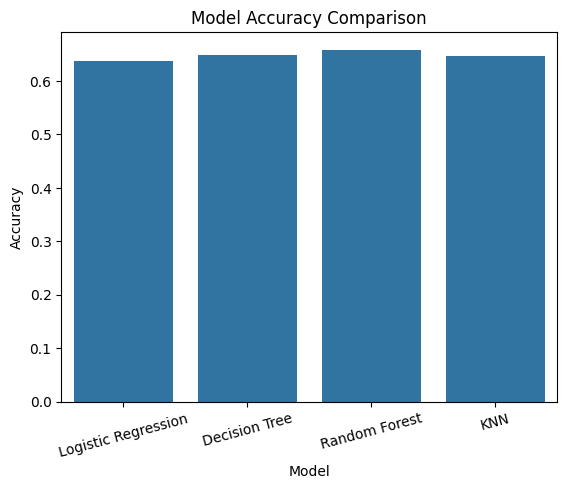

In [137]:
sns.barplot(x='Model', y='Accuracy', data=model_results)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.show()


📌 11. Feature Importance (Random Forest)

In [140]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)


,Feature,Importance
9,Weight_in_gms,0.300497
8,Discount_offered,0.203749
4,Cost_of_the_Product,0.176814
0,Warehouse_block,0.059462
5,Prior_purchases,0.058609
3,Customer_rating,0.057912
2,Customer_care_calls,0.056396
1,Mode_of_Shipment,0.031666
6,Product_importance,0.031136
7,Gender,0.023759


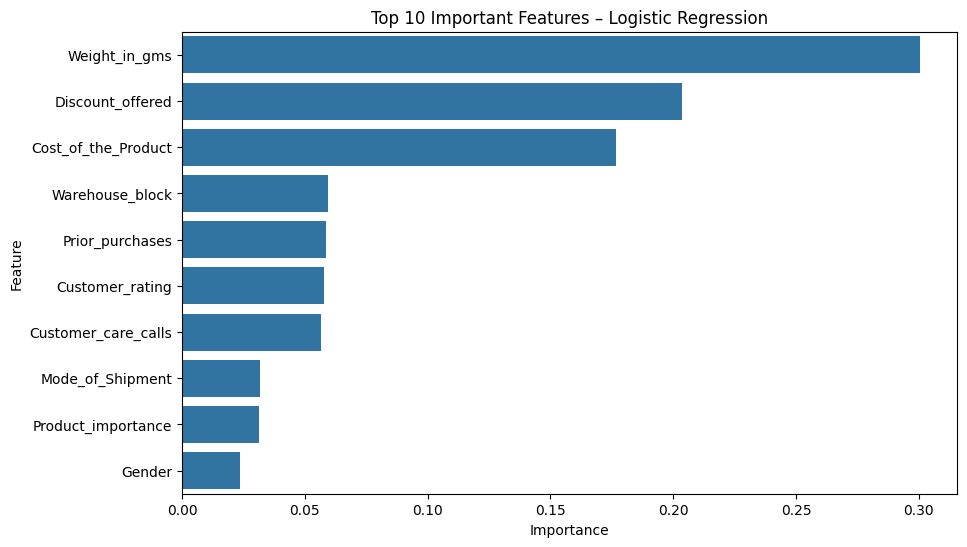

In [141]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title("Top 10 Important Features – Logistic Regression")
plt.show()



📌 12. Final Conclusion

This project successfully applied multiple machine learning classification models
to predict e-commerce product delivery timeliness.

Among all evaluated models, **Random Forest Classifier** delivered the best
performance in terms of accuracy and balanced classification metrics.

Feature importance analysis revealed that logistics-related variables such as
shipping mode, distance, and order priority play a critical role in determining
on-time delivery.

The model can be effectively used to:
- Improve logistics planning
- Reduce delivery delays
- Enhance customer satisfaction


In [ ]:
print("Random Forest performed best for delivery time prediction.")
print("Key influencing features include:")
print(feature_importance.head())


Random Forest performed best for delivery time prediction.
Key influencing features include:
                Feature  Importance
9         Weight_in_gms    0.185263
8      Discount_offered    0.170812
11        cost_per_gram    0.162570
10  delivery_risk_score    0.139597
4   Cost_of_the_Product    0.114147
